# 01 - Load and Understand Raw Data

## Objective

Before building the onboarding funnel or analysing airport supply, let us try to understand the structure and quality of the seven raw datasets.

This notebook focuses on:

- dataset size and grain
- column structure and data types
- timestamps and the extraction cutoff
- categorical values
- key and referential-integrity checks
- basic numerical sanity checks
- data quality issues that could affect later analysis

No cleaning or business conclusions are performed here. The goal is to establish a reliable starting point for the analysis.

## 1. Load the seven raw datasets

The assignment provides five datasets for captain onboarding and two datasets for airport supply.

The data was extracted at **2026-06-30 23:59 IST**, so that cutoff will be important when interpreting recent cohorts and downstream activity.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
captains = pd.read_csv("../data/captains.csv")
captains.head(5)

,captain_id,signup_ts,city,vehicle_type,acquisition_channel,signup_zone_id,device_tier,app_language,age_band
0,CPT104359,2026-01-01 06:08:00,Pune,Auto,organic_app,PUN-Z23,low,kn,25-34
1,CPT120008,2026-01-01 06:52:00,Pune,Cab,referral,PUN-Z05,mid,mr,45+
2,CPT102049,2026-01-01 07:02:00,Hyderabad,Cab,organic_app,HYD-Z01,high,te,35-44
3,CPT123006,2026-01-01 07:15:00,Pune,Cab,organic_app,PUN-Z11,high,hi,25-34
4,CPT102642,2026-01-01 07:27:00,Bangalore,ERickshaw,gc_telecalling,BAN-Z06,low,hi,18-24


In [3]:
doc_events = pd.read_csv("../data/doc_events.csv")
doc_events.head(5)

,event_id,captain_id,doc_type,attempt_no,event_type,event_ts,failure_reason
0,EV000000000,CPT104359,DL,1,upload_success,2026-01-01 20:30:06.229672479,NaN
1,EV000000001,CPT104359,DL,1,verification_pass,2026-01-01 23:26:54.472703731,NaN
2,EV000000002,CPT104359,RC,1,upload_success,2026-01-02 09:36:49.336302871,NaN
3,EV000000003,CPT104359,RC,1,verification_pass,2026-01-02 12:41:51.324092998,NaN
4,EV000000004,CPT104359,AADHAAR,1,upload_success,2026-01-02 14:06:20.401070690,NaN


In [4]:
approvals = pd.read_csv("../data/approvals.csv")
approvals.head(5)

,captain_id,decision_ts,final_status,last_stage_reached,docs_cleared
0,CPT104359,2026-01-06 08:11:48.775157583,approved,NaN,6
1,CPT120008,NaN,dropped_in_docs,AADHAAR,2
2,CPT102049,NaN,dropped_in_docs,PERMIT,3
3,CPT123006,NaN,dropped_in_docs,INSURANCE,5
4,CPT102642,NaN,dropped_in_docs,PERMIT,3


In [5]:
activation = pd.read_csv("../data/activation.csv")
activation.head(5)

,captain_id,first_order_ts,orders_d7,orders_d30,online_hours_d30
0,CPT104359,2026-01-11 12:11:54.524199600,7.0,33.0,26.9
1,CPT105916,2026-01-08 04:16:11.743250188,15.0,48.0,29.1
2,CPT115782,2026-01-10 11:14:57.939110321,9.0,31.0,20.2
3,CPT124093,2026-01-09 16:35:45.322422039,8.0,13.0,11.4
4,CPT101207,2026-01-09 18:43:22.114690071,4.0,9.0,6.1


In [6]:
nudges = pd.read_csv("../data/nudges.csv")
nudges.head(5)

,captain_id,campaign_id,channel,sent_ts,delivered,clicked
0,CPT104359,CAMP_SMS_004,sms,2026-01-02 01:31:34.373244464,1,0
1,CPT102049,CAMP_WA_002,whatsapp,2026-01-02 20:02:31.634258914,1,0
2,CPT123006,CAMP_WA_002,whatsapp,2026-01-03 11:32:05.154545929,1,1
3,CPT105916,CAMP_WA_002,whatsapp,2026-01-05 01:25:34.559467887,1,1
4,CPT107181,CAMP_WA_001,whatsapp,2026-01-01 23:10:49.644254087,1,0


In [7]:
airport_hourly = pd.read_csv("../data/airport_hourly.csv")
airport_hourly.head(5)

,zone_id,zone_type,hour_ts,requests,fulfilled_requests,unfulfilled_requests,online_captains,avg_eta_min,avg_surge_multiplier
0,APT-T1,airport_terminal,2026-05-01 00:00:00,83,31,52,15,9.13,2.04
1,APT-T1,airport_terminal,2026-05-01 01:00:00,111,27,84,10,10.13,2.17
2,APT-T1,airport_terminal,2026-05-01 02:00:00,86,21,65,13,10.89,2.19
3,APT-T1,airport_terminal,2026-05-01 03:00:00,54,25,29,15,9.27,1.80
4,APT-T1,airport_terminal,2026-05-01 04:00:00,36,34,2,17,4.54,1.08


In [8]:
airport_trips = pd.read_csv("../data/airport_trips.csv")
airport_trips.head(5)

,trip_id,pickup_zone_id,drop_zone_id,drop_zone_type,request_ts,trip_distance_km,captain_cancelled,got_return_fare_within_20min,fare_inr
0,TRP00036169,APT-T1,CBD-02,city_core,2026-05-01 00:00:00,8.18,0,1,148.0
1,TRP00018764,APT-T1,SUB-07,suburban,2026-05-01 00:00:00,21.10,0,0,302.0
2,TRP00027350,APT-T2,TECH-03,tech_park,2026-05-01 00:00:00,14.22,0,0,231.0
3,TRP00058214,APT-T2,TECH-03,tech_park,2026-05-01 00:00:00,9.81,0,0,207.0
4,TRP00044709,APT-T1,SUB-07,suburban,2026-05-01 00:00:00,18.02,1,0,333.0


In [9]:
datasets = {
    "captains": captains,
    "doc_events": doc_events,
    "approvals": approvals,
    "activation": activation,
    "nudges": nudges,
    "airport_hourly": airport_hourly,
    "airport_trips": airport_trips
}

In [10]:
print(f"Loaded {len(datasets)} datasets.")

Loaded 7 datasets.


In [11]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

captains: (25000, 9)
doc_events: (186282, 7)
approvals: (25000, 5)
activation: (4206, 5)
nudges: (16314, 6)
airport_hourly: (10248, 9)
airport_trips: (60000, 9)


## Dataset Inventory

In [12]:
inventory = pd.DataFrame({
    "dataset": datasets.keys(),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()]
})

In [13]:
inventory["rows"] = inventory["rows"].map(lambda x: f"{x:,}")
inventory

,dataset,rows,columns
0,captains,"25,000",9
1,doc_events,"186,282",7
2,approvals,"25,000",5
3,activation,"4,206",5
4,nudges,"16,314",6
5,airport_hourly,"10,248",9
6,airport_trips,"60,000",9


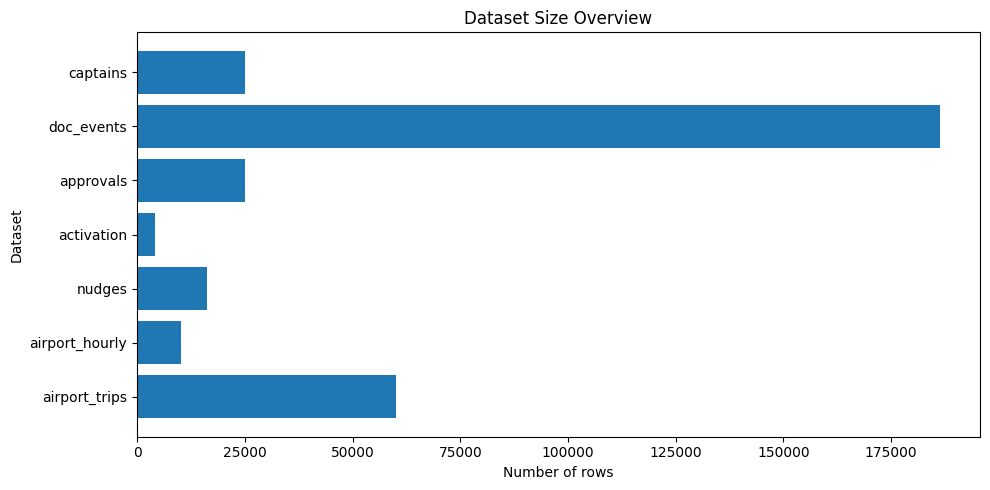

In [14]:
inventory_plot = inventory.copy()
inventory_plot["rows_numeric"] = (
    inventory_plot["rows"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

plt.figure(figsize=(10, 5))
plt.barh(inventory_plot["dataset"], inventory_plot["rows_numeric"])
plt.xlabel("Number of rows")
plt.ylabel("Dataset")
plt.title("Dataset Size Overview")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**What this tells us**

`doc_events` and `airport_trips` are much larger than the captain-level tables because they contain repeated observations per captain or trip. Therefore, row count should not be interpreted as business importance or population size.

This also confirms why we need to understand the grain of each dataset before joining or aggregating them.

## 2. Schema overview

The datasets operate at different grains. That distinction matters later because event level tables cannot be joined to captain level tables blindly without creating duplicate captain rows.

In [15]:
schema_rows = []

for name, df in datasets.items():
    for column in df.columns:
        schema_rows.append(
            {
                "dataset": name,
                "column": column,
                "dtype": str(df[column].dtype),
                "missing": int(df[column].isna().sum()),
            }
        )

In [16]:
schema = pd.DataFrame(schema_rows)
display(schema)

,dataset,column,dtype,missing
0,captains,captain_id,object,0
1,captains,signup_ts,object,0
2,captains,city,object,0
3,captains,vehicle_type,object,0
4,captains,acquisition_channel,object,0
5,captains,signup_zone_id,object,0
6,captains,device_tier,object,0
7,captains,app_language,object,0
8,captains,age_band,object,0
9,doc_events,event_id,object,0


In [17]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * len(name))
    print(df.columns.tolist())


CAPTAINS
--------
['captain_id', 'signup_ts', 'city', 'vehicle_type', 'acquisition_channel', 'signup_zone_id', 'device_tier', 'app_language', 'age_band']

DOC_EVENTS
----------
['event_id', 'captain_id', 'doc_type', 'attempt_no', 'event_type', 'event_ts', 'failure_reason']

APPROVALS
---------
['captain_id', 'decision_ts', 'final_status', 'last_stage_reached', 'docs_cleared']

ACTIVATION
----------
['captain_id', 'first_order_ts', 'orders_d7', 'orders_d30', 'online_hours_d30']

NUDGES
------
['captain_id', 'campaign_id', 'channel', 'sent_ts', 'delivered', 'clicked']

AIRPORT_HOURLY
--------------
['zone_id', 'zone_type', 'hour_ts', 'requests', 'fulfilled_requests', 'unfulfilled_requests', 'online_captains', 'avg_eta_min', 'avg_surge_multiplier']

AIRPORT_TRIPS
-------------
['trip_id', 'pickup_zone_id', 'drop_zone_id', 'drop_zone_type', 'request_ts', 'trip_distance_km', 'captain_cancelled', 'got_return_fare_within_20min', 'fare_inr']


## 3. Dataset grain and key checks

Expected grain:

| Dataset | Expected grain |
|---|---|
| `captains` | one row per signup/captain |
| `doc_events` | one row per document event |
| `approvals` | one row per captain |
| `activation` | one row per approved captain |
| `nudges` | one row per captain × campaign exposure |
| `airport_hourly` | one row per zone × hour |
| `airport_trips` | one row per sampled airport trip |

The checks below confirm whether the raw data follows these expectations.

In [18]:
key_checks = {
    "captains": ["captain_id"],
    "doc_events": ["event_id"],
    "approvals": ["captain_id"],
    "activation": ["captain_id"],
    "airport_trips": ["trip_id"],
}

In [19]:
key_rows = []

for name, keys in key_checks.items():
    df = datasets[name]
    unique_keys = df[keys].drop_duplicates().shape[0]
    key_rows.append(
        {
            "dataset": name,
            "rows": len(df),
            "unique_keys": unique_keys,
            "duplicate_key_rows": len(df) - unique_keys,
        }
    )

In [20]:
key_summary = pd.DataFrame(key_rows)
key_summary

,dataset,rows,unique_keys,duplicate_key_rows
0,captains,25000,25000,0
1,doc_events,186282,186282,0
2,approvals,25000,25000,0
3,activation,4206,4206,0
4,airport_trips,60000,60000,0


In [21]:
nudge_grain = (
    nudges.groupby(["captain_id", "campaign_id"])
    .size()
    .rename("rows_per_captain_campaign")
)

In [22]:
print("Nudge rows per captain × campaign:")
display(nudge_grain.describe().to_frame().T)

Nudge rows per captain × campaign:


,count,mean,std,min,25%,50%,75%,max
rows_per_captain_campaign,16314.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [23]:
hourly_grain = (
    airport_hourly.groupby(["zone_id", "hour_ts"])
    .size()
    .rename("rows_per_zone_hour")
)

In [24]:
print("\nAirport hourly rows per zone × hour:")
display(hourly_grain.value_counts().sort_index().to_frame("row_count"))


Airport hourly rows per zone × hour:


,row_count
rows_per_zone_hour,
1,10248


## 4. Sample records

A small sample is enough to understand the shape of each table without filling the notebook with repeated full table dumps.

In [25]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head(3))


captains


,captain_id,signup_ts,city,vehicle_type,acquisition_channel,signup_zone_id,device_tier,app_language,age_band
0,CPT104359,2026-01-01 06:08:00,Pune,Auto,organic_app,PUN-Z23,low,kn,25-34
1,CPT120008,2026-01-01 06:52:00,Pune,Cab,referral,PUN-Z05,mid,mr,45+
2,CPT102049,2026-01-01 07:02:00,Hyderabad,Cab,organic_app,HYD-Z01,high,te,35-44



doc_events


,event_id,captain_id,doc_type,attempt_no,event_type,event_ts,failure_reason
0,EV000000000,CPT104359,DL,1,upload_success,2026-01-01 20:30:06.229672479,NaN
1,EV000000001,CPT104359,DL,1,verification_pass,2026-01-01 23:26:54.472703731,NaN
2,EV000000002,CPT104359,RC,1,upload_success,2026-01-02 09:36:49.336302871,NaN



approvals


...

,captain_id,campaign_id,channel,sent_ts,delivered,clicked
0,CPT104359,CAMP_SMS_004,sms,2026-01-02 01:31:34.373244464,1,0
1,CPT102049,CAMP_WA_002,whatsapp,2026-01-02 20:02:31.634258914,1,0
2,CPT123006,CAMP_WA_002,whatsapp,2026-01-03 11:32:05.154545929,1,1



airport_hourly


,zone_id,zone_type,hour_ts,requests,fulfilled_requests,unfulfilled_requests,online_captains,avg_eta_min,avg_surge_multiplier
0,APT-T1,airport_terminal,2026-05-01 00:00:00,83,31,52,15,9.13,2.04
1,APT-T1,airport_terminal,2026-05-01 01:00:00,111,27,84,10,10.13,2.17
2,APT-T1,airport_terminal,2026-05-01 02:00:00,86,21,65,13,10.89,2.19



airport_trips


,trip_id,pickup_zone_id,drop_zone_id,drop_zone_type,request_ts,trip_distance_km,captain_cancelled,got_return_fare_within_20min,fare_inr
0,TRP00036169,APT-T1,CBD-02,city_core,2026-05-01 00:00:00,8.18,0,1,148.0
1,TRP00018764,APT-T1,SUB-07,suburban,2026-05-01 00:00:00,21.10,0,0,302.0
2,TRP00027350,APT-T2,TECH-03,tech_park,2026-05-01 00:00:00,14.22,0,0,231.0


## 5. Categorical values

These are the main categorical dimensions available for later segmentation.

The document sequence from the brief is:

1. DL - all
2. RC - all
3. Aadhaar - all
4. Permit - Auto and Cab
5. Fitness - all
6. Insurance - all

The different applicability of Permit will be important when defining the onboarding funnel.

In [26]:
categorical_columns = {
    "captains": [
        "city",
        "vehicle_type",
        "acquisition_channel",
        "device_tier",
        "app_language",
        "age_band",
    ],
    "doc_events": [
        "doc_type",
        "event_type",
        "failure_reason",
    ],
    "approvals": [
        "final_status",
        "last_stage_reached",
    ],
    "nudges": [
        "campaign_id",
        "channel",
    ],
    "airport_hourly": [
        "zone_type",
    ],
    "airport_trips": [
        "drop_zone_type",
    ],
}

In [27]:
for dataset, columns in categorical_columns.items():
    print(f"\n{dataset.upper()}")
    print("-" * len(dataset))
    for column in columns:
        print(f"\n{column}")
        print(datasets[dataset][column].value_counts(dropna=False))


CAPTAINS
--------

city
city
Hyderabad    7663
Delhi        6452
Pune         5448
Bangalore    5437
Name: count, dtype: int64

vehicle_type
vehicle_type
Auto         11363
Cab           8881
ERickshaw     4756
Name: count, dtype: int64

acquisition_channel
acquisition_channel
organic_app       8418
fos_field         6122
referral          5518
paid_digital      3483
gc_telecalling    1459
Name: count, dtype: int64

device_tier
device_tier
low     11565
mid      9533
high     3902
Name: count, dtype: int64

app_language
app_language
kn    5081
te    5064
mr    4956
en    4952
hi    4947
Name: count, dtype: int64

age_band
age_band
25-34    10397
35-44     7086
18-24     4540
45+       2977
Name: count, dtype: int64

DOC_EVENTS
----------

doc_type
doc_type
DL           50780
RC           48099
AADHAAR      31117
FITNESS      21884
PERMIT       20807
INSURANCE    13595
Name: count, dtype: int64

event_type
event_type
upload_success       93236
verification_pass    73274
verification_fa

## 6. Timestamp coverage

The airport datasets cover **May - June 2026**, while the captain onboarding data covers the broader January June period.

This difference in observation windows means the airport analysis should be treated as a separate marketplace view rather than directly combined with the full onboarding cohort.

In [28]:
timestamp_columns = {
    "captains": ["signup_ts"],
    "doc_events": ["event_ts"],
    "approvals": ["decision_ts"],
    "activation": ["first_order_ts"],
    "nudges": ["sent_ts"],
    "airport_hourly": ["hour_ts"],
    "airport_trips": ["request_ts"],
}

In [29]:
timestamp_summary = []

for dataset, columns in timestamp_columns.items():
    for column in columns:
        values = pd.to_datetime(datasets[dataset][column], errors="coerce")
        timestamp_summary.append(
            {
                "dataset": dataset,
                "column": column,
                "min": values.min(),
                "max": values.max(),
                "null_after_parse": int(values.isna().sum()),
            }
        )

In [30]:
timestamp_summary = pd.DataFrame(timestamp_summary)
timestamp_summary

,dataset,column,min,max,null_after_parse
0,captains,signup_ts,2026-01-01 06:08:00.000000000,2026-06-30 21:57:00.000000000,0
1,doc_events,event_ts,2026-01-01 13:30:50.795752785,2026-06-30 23:56:42.723769018,0
2,approvals,decision_ts,2026-01-05 21:40:24.347261353,2026-06-30 22:26:04.692838376,20359
3,activation,first_order_ts,2026-01-06 11:57:58.804450784,2026-06-30 21:36:06.089121524,102
4,nudges,sent_ts,2026-01-01 23:10:49.644254087,2026-06-30 23:37:42.004031897,0
5,airport_hourly,hour_ts,2026-05-01 00:00:00.000000000,2026-06-30 23:00:00.000000000,0
6,airport_trips,request_ts,2026-05-01 00:00:00.000000000,2026-06-30 23:00:00.000000000,0


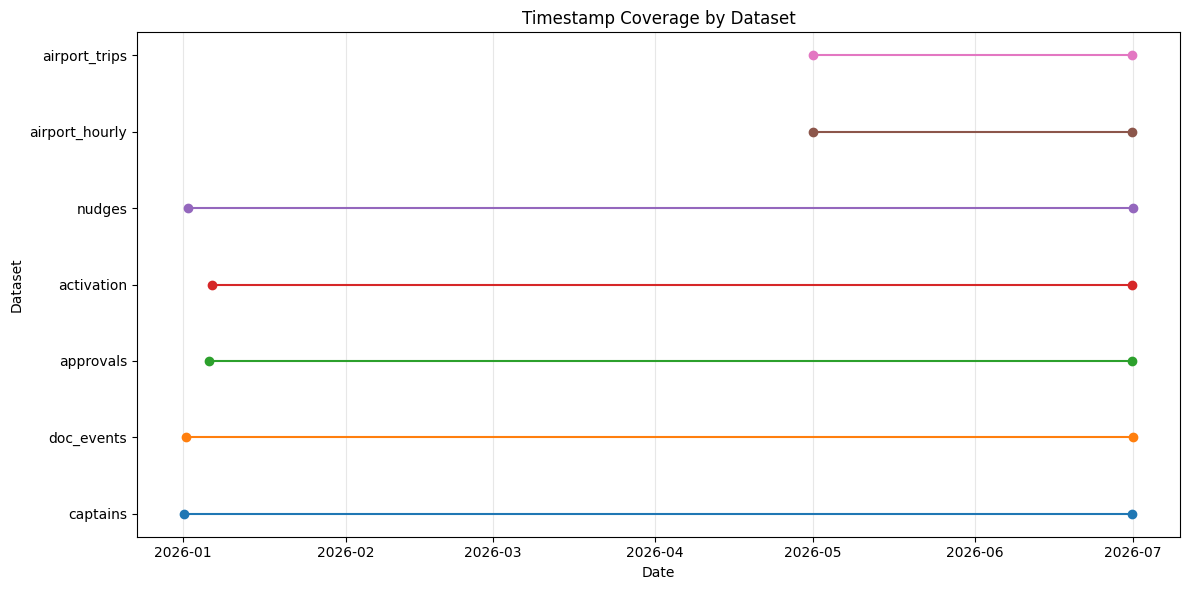

In [31]:
timestamp_plot = timestamp_summary.copy()

timestamp_plot["min"] = pd.to_datetime(timestamp_plot["min"])
timestamp_plot["max"] = pd.to_datetime(timestamp_plot["max"])

plt.figure(figsize=(12, 6))

for _, row in timestamp_plot.iterrows():
    plt.plot(
        [row["min"], row["max"]],
        [row["dataset"], row["dataset"]],
        marker="o"
    )

plt.xlabel("Date")
plt.ylabel("Dataset")
plt.title("Timestamp Coverage by Dataset")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**What this tells us**

The onboarding datasets cover January–June 2026, while the airport datasets cover May–June 2026. All datasets fall within the extraction cutoff of June 30, 2026.

This means onboarding and airport analyses should be treated as separate analytical views rather than assuming they represent the same observation window.

## 7. Extraction cutoff check

The assignment states that all seven datasets were extracted at **2026-06-30 23:59 IST**.

I check each timestamped dataset for records after that point rather than silently assuming the cutoff is respected.

In [32]:
cutoff = pd.Timestamp("2026-06-30 23:59:59")

In [33]:
cutoff_checks = []

for dataset, column in {
    "captains": "signup_ts",
    "doc_events": "event_ts",
    "approvals": "decision_ts",
    "activation": "first_order_ts",
    "nudges": "sent_ts",
    "airport_hourly": "hour_ts",
    "airport_trips": "request_ts",
}.items():
    ts = pd.to_datetime(datasets[dataset][column], errors="coerce")
    cutoff_checks.append(
        {
            "dataset": dataset,
            "timestamp_column": column,
            "records_after_cutoff": int((ts > cutoff).sum()),
        }
    )

In [34]:
pd.DataFrame(cutoff_checks)

,dataset,timestamp_column,records_after_cutoff
0,captains,signup_ts,0
1,doc_events,event_ts,0
2,approvals,decision_ts,0
3,activation,first_order_ts,0
4,nudges,sent_ts,0
5,airport_hourly,hour_ts,0
6,airport_trips,request_ts,0


## 8. Basic numerical sanity checks

These checks are deliberately simple. They are intended to catch impossible or internally inconsistent values before analysis.

In [35]:
# Airport request accounting
airport_hourly["fulfillment_check"] = (
    airport_hourly["fulfilled_requests"]
    + airport_hourly["unfulfilled_requests"]
    - airport_hourly["requests"]
)

In [36]:
print("Airport rows where fulfilled + unfulfilled != requests:")
print((airport_hourly["fulfillment_check"] != 0).sum())

Airport rows where fulfilled + unfulfilled != requests:
0


In [37]:
airport_hourly.drop(columns="fulfillment_check", inplace=True)

In [38]:
# Activation ordering
print("\nActivation rows where D7 orders exceed D30 orders:")
display(
    activation.loc[
        activation["orders_d7"] > activation["orders_d30"],
        ["captain_id", "orders_d7", "orders_d30"],
    ]
)


Activation rows where D7 orders exceed D30 orders:


,captain_id,orders_d7,orders_d30
1525,CPT123585,4.0,3.0
1919,CPT123478,4.0,3.0
2048,CPT103607,7.0,6.0
2665,CPT124543,10.0,7.0
2770,CPT112526,6.0,5.0
3087,CPT116344,6.0,5.0
3347,CPT105360,4.0,3.0


In [39]:
# Negative numeric values
print("\nNegative numeric values by dataset:")

for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include="number").columns
    negatives = (df[numeric_cols] < 0).sum()
    negatives = negatives[negatives > 0]

    if len(negatives):
        print(f"\n{name}")
        print(negatives)


Negative numeric values by dataset:


In [40]:
print("Airport trip distance/fare summary:")
display(airport_trips[["trip_distance_km", "fare_inr"]].describe().T)

Airport trip distance/fare summary:


,count,mean,std,min,25%,50%,75%,max
trip_distance_km,60000.0,17.883161,8.117206,1.54,11.82,16.62,22.66,66.73
fare_inr,60000.0,279.349983,111.685797,50.00,197.00,263.00,345.00,931.00


In [41]:
print("\nMissing airport trip distance/fare values:")
display(airport_trips[["trip_distance_km", "fare_inr"]].isna().sum().to_frame("missing").T)


Missing airport trip distance/fare values:


,trip_distance_km,fare_inr
missing,0,0


## 9. Missing values

Missingness is not automatically a data error. Some fields are naturally missing depending on the captain's stage or event type.

The purpose here is to identify where missingness exists so that later analysis can interpret it deliberately.

In [42]:
missing_rows = []

for name, df in datasets.items():
    for column in df.columns:
        count = int(df[column].isna().sum())
        if count:
            missing_rows.append(
                {
                    "dataset": name,
                    "column": column,
                    "missing_count": count,
                    "missing_pct": round(100 * count / len(df), 2),
                }
            )

In [43]:
missing_summary = pd.DataFrame(missing_rows)

if len(missing_summary):
    display(
        missing_summary.sort_values(
            ["dataset", "missing_pct"],
            ascending=[True, False],
        )
    )
else:
    print("No missing values found.")

,dataset,column,missing_count,missing_pct
5,activation,orders_d30,834,19.83
6,activation,online_hours_d30,834,19.83
4,activation,orders_d7,187,4.45
3,activation,first_order_ts,102,2.43
1,approvals,decision_ts,20359,81.44
2,approvals,last_stage_reached,4393,17.57
0,doc_events,failure_reason,166510,89.39


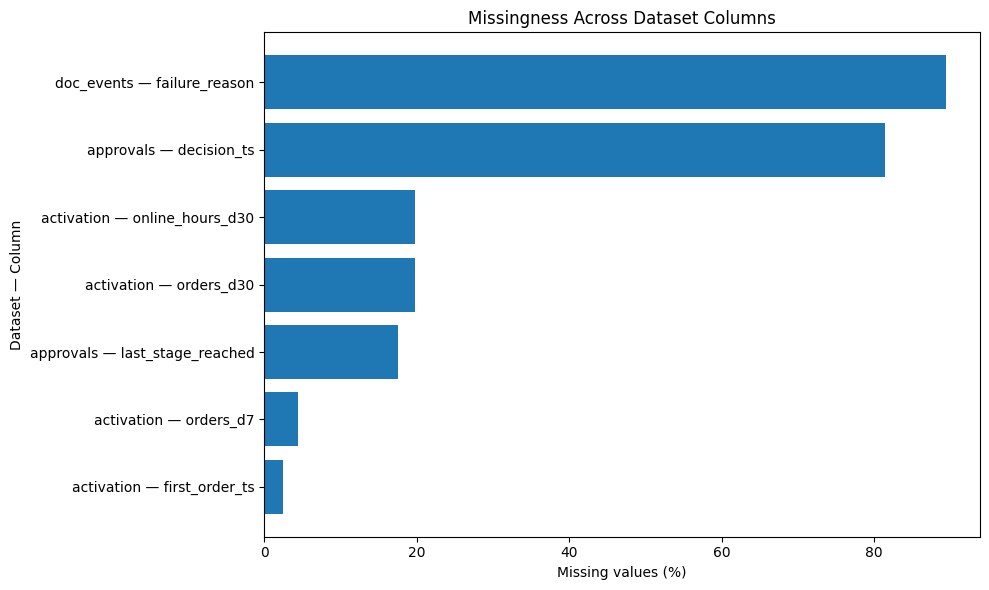

In [44]:
missing_plot = missing_summary.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    missing_plot["dataset"] + " — " + missing_plot["column"],
    missing_plot["missing_pct"]
)
plt.xlabel("Missing values (%)")
plt.ylabel("Dataset — Column")
plt.title("Missingness Across Dataset Columns")
plt.tight_layout()
plt.show()

**What this tells us**

Missingness is concentrated in a few fields:
- `approvals.decision_ts` is frequently missing because not every captain has reached a terminal decision.
- `doc_events.failure_reason` is mostly missing because failure reasons are generally relevant only to failed verification events.
- Several activation outcome fields are missing because some approved captains do not yet have complete post-activation observation.

Therefore, missing values will not be automatically imputed or treated as data errors. Their business meaning needs to be considered during downstream analysis.

## 10. Referential integrity

The event, approval, activation and nudge tables should only contain captain IDs that exist in `captains.csv`.

Activation is also expected to contain only captains whose terminal onboarding status is approved.

In [45]:
captain_ids = set(captains["captain_id"])

In [46]:
referential_checks = {
    "doc_events → captains": set(doc_events["captain_id"]).issubset(captain_ids),
    "approvals → captains": set(approvals["captain_id"]).issubset(captain_ids),
    "activation → captains": set(activation["captain_id"]).issubset(captain_ids),
    "nudges → captains": set(nudges["captain_id"]).issubset(captain_ids),
}

In [47]:
for check, result in referential_checks.items():
    print(f"{check}: {result}")

approved_ids = set(
    approvals.loc[approvals["final_status"] == "approved", "captain_id"]
)

print(
    "Activation subset of approved captains:",
    set(activation["captain_id"]).issubset(approved_ids),
)

doc_events → captains: True
approvals → captains: True
activation → captains: True
nudges → captains: True
Activation subset of approved captains: True


## 11. Event-level consistency checks

A document failure should have a failure reason, while non-failure events should not.

Similarly, a nudge marked as clicked but not delivered is logically unusual and should be flagged rather than silently corrected.

In [48]:
failure_reason_inconsistency = doc_events[
    (
        doc_events["failure_reason"].notna()
        & (doc_events["event_type"] != "verification_fail")
    )
    |
    (
        doc_events["failure_reason"].isna()
        & (doc_events["event_type"] == "verification_fail")
    )
]

In [49]:
print(
    "Rows with inconsistent failure_reason/event_type:",
    len(failure_reason_inconsistency),
)

Rows with inconsistent failure_reason/event_type: 0


In [50]:
invalid_nudges = nudges[
    (nudges["clicked"] == 1)
    & (nudges["delivered"] == 0)
]

print("Clicks without delivery:", len(invalid_nudges))

Clicks without delivery: 457


In [51]:
invalid_attempts = doc_events[
    ~doc_events["attempt_no"].between(1, 3)
]

print("Document events with attempt_no outside 1–3:", len(invalid_attempts))

Document events with attempt_no outside 1–3: 0


In [52]:
print("\nDocument attempt distribution:")
display(doc_events["attempt_no"].value_counts().sort_index().to_frame("events"))


Document attempt distribution:


,events
attempt_no,
1,162176
2,21863
3,2243


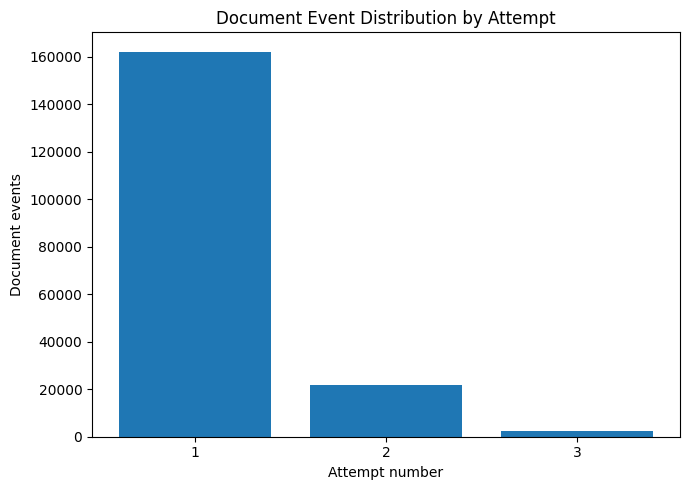

In [53]:
attempt_counts = (
    doc_events["attempt_no"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))
plt.bar(
    attempt_counts.index.astype(str),
    attempt_counts.values
)
plt.xlabel("Attempt number")
plt.ylabel("Document events")
plt.title("Document Event Distribution by Attempt")
plt.tight_layout()
plt.show()

**What this tells us**

Most document events occur on the first attempt, with progressively fewer events on attempts 2 and 3. Since the business process allows up to three attempts, this distribution is consistent with the expected retry structure.

The existence of attempts 2 and 3 also means that downstream funnel analysis should distinguish between:
- initial document submission,
- successful completion after retry,
- and failure/drop-off despite retries.

# Final Conclusion - What We Know Before Analysis

## 1. Purpose of this notebook

This notebook establishes the starting point for the Rapido captain-acquisition analysis. The objective was **not to clean the data or answer the business questions yet**, but to understand what data is available, what one row represents in each dataset, whether the tables are structurally reliable, and what data-quality issues must be handled deliberately in later notebooks.

The assignment has two related business areas:

* **Captain onboarding / activation:** understand the journey from signup → approval → first order.
* **Airport supply:** understand demand–supply pressure around airport terminals and whether acquiring more airport-area captains is the right intervention.

The assignment defines two key business metrics:

* **A2O (Acquisition to Onboarded):** signup → approved.
* **R2A (Registered to Active):** signup → first order completed.

A2O is the primary onboarding outcome; R2A extends the journey into actual post-approval activity.

---

## 2. Data inventory and grain

Seven raw datasets are available:

| Dataset          | Grain              | What one row represents                           |
| ---------------- | ------------------ | ------------------------------------------------- |
| `captains`       | Captain / signup   | One captain signup                                |
| `doc_events`     | Document event     | One upload or verification event for one document |
| `approvals`      | Captain            | One captain's terminal onboarding outcome         |
| `activation`     | Approved captain   | One approved captain's post-approval activity     |
| `nudges`         | Captain × campaign | One campaign exposure for one captain             |
| `airport_hourly` | Zone × hour        | One hourly marketplace state for one zone         |
| `airport_trips`  | Trip               | One sampled airport-origin trip                   |

The seven datasets contain 25,000 signup records, 186,282 document events, 25,000 approval records, 4,206 activation records, 16,314 nudge records, 10,248 airport-hour observations and 60,000 airport trips.

The different grains are important: `captains`, `approvals` and `activation` are captain-level tables, while `doc_events` is event-level and `airport_hourly` is zone-hour-level. These tables therefore **cannot be joined mechanically** without first deciding the intended unit of analysis; otherwise a single captain can be duplicated across multiple document events.

---

## 3. What each dataset tells us

### `captains`

This is the **signup-level base population**.

* `captain_id` — unique captain identifier.
* `signup_ts` — time of signup.
* `city` — signup city.
* `vehicle_type` — vehicle category.
* `acquisition_channel` — source through which the captain was acquired.
* `signup_zone_id` — zone associated with signup.
* `device_tier` — device category.
* `app_language` — language selected/used in the app.
* `age_band` — captain age group.

This table will provide the denominator and segmentation dimensions for the onboarding analysis.

### `doc_events`

This is the **event-level onboarding history**.

* `event_id` — unique document event.
* `captain_id` — captain associated with the event.
* `doc_type` — document involved.
* `attempt_no` — document attempt number.
* `event_type` — `upload_success`, `verification_pass`, or `verification_fail`.
* `event_ts` — event timestamp.
* `failure_reason` — reason associated with a verification failure.

A captain can therefore have many rows here because a document may require multiple attempts.

### `approvals`

This is the **terminal onboarding outcome**.

* `captain_id` — captain identifier.
* `decision_ts` — time of final decision, where applicable.
* `final_status` — `approved`, `rejected`, `dropped_in_docs`, or `in_progress`.
* `last_stage_reached` — latest onboarding stage recorded for non-approved outcomes.
* `docs_cleared` — number of documents cleared.

This table will be central to defining the A2O funnel.

### `activation`

This contains **post-approval activity for approved captains**.

* `captain_id` — captain identifier.
* `first_order_ts` — timestamp of first completed order.
* `orders_d7` — orders in the first 7 days.
* `orders_d30` — orders in the first 30 days.
* `online_hours_d30` — online hours during the 30-day period.

This table allows the analysis to move beyond approval toward R2A and post-approval activity.

### `nudges`

This records **onboarding communication exposures**.

* `captain_id` — captain receiving the communication.
* `campaign_id` — campaign identifier.
* `channel` — communication channel.
* `sent_ts` — time sent.
* `delivered` — whether the communication was delivered.
* `clicked` — whether the communication was clicked.

The important campaign for later analysis is `CAMP_WA_002`. The campaign analysis must be performed at the **captain/exposure level**, not by blindly counting event rows.

### `airport_hourly`

This captures the **hourly marketplace state by zone**.

* `zone_id` — geographic/market zone.
* `zone_type` — type of zone.
* `hour_ts` — hour being measured.
* `requests` — total requests.
* `fulfilled_requests` — requests successfully fulfilled.
* `unfulfilled_requests` — requests not fulfilled.
* `online_captains` — captains online.
* `avg_eta_min` — average estimated arrival time.
* `avg_surge_multiplier` — average surge multiplier.

The natural grain is one `zone_id × hour_ts`.

### `airport_trips`

This contains sampled **airport-origin trips**.

* `trip_id` — unique trip identifier.
* `pickup_zone_id` — airport pickup zone.
* `drop_zone_id` — destination zone.
* `drop_zone_type` — destination type.
* `request_ts` — trip request timestamp.
* `trip_distance_km` — trip distance.
* `captain_cancelled` — whether the captain cancelled.
* `got_return_fare_within_20min` — whether the captain obtained another fare within 20 minutes.
* `fare_inr` — trip fare.

This dataset will later help determine whether airport trips create a genuine supply problem after the initial trip, rather than simply indicating that more captains are needed.

---

## 4. Onboarding rules we must preserve

The required document sequence is:

1. **Driving Licence (DL)** — all captains
2. **Registration Certificate (RC)** — all captains
3. **Aadhaar** — all captains
4. **Permit** — Auto and Cab only
5. **Fitness Certificate** — all captains
6. **Insurance** — all captains

Each document can be uploaded and verified. Failed documents can be re-uploaded up to three attempts.

The **Permit exception is important**: it must not be treated as a required stage for ERickshaw captains when constructing the funnel.

---

## 5. Time coverage and cohort implications

The raw data was extracted at **2026-06-30 23:59 IST**.

The onboarding-related datasets cover January–June 2026, while the airport datasets cover May–June 2026. Therefore, the airport analysis will be treated as a separate marketplace view rather than directly combined with the full onboarding cohort.

The extraction cutoff also creates a **cohort-maturity issue**: captains who signed up close to June 30 may not have had enough time to complete onboarding, receive a final decision, or reach downstream activity. Later funnel and R2A analysis therefore needs an explicit cohorting/maturity rule rather than assuming every signup has had equal opportunity to progress.

No timestamped record was found after the stated extraction cutoff.

---

## 6. Structural and data-quality findings

### Keys and grain

The tested primary keys are unique for:

* `captains` → `captain_id`
* `doc_events` → `event_id`
* `approvals` → `captain_id`
* `activation` → `captain_id`
* `airport_trips` → `trip_id`

The airport hourly table also satisfies its expected `zone_id × hour_ts` grain, with exactly one row per zone-hour. Nudge data similarly has exactly one row per captain × campaign exposure.

### Missingness

Missing values are present, but they are **not automatically errors**.

Important examples:

* `doc_events.failure_reason` is missing for most rows because a failure reason is relevant primarily to verification failures.
* `approvals.decision_ts` is missing for many non-terminal outcomes.
* `approvals.last_stage_reached` is naturally absent for some outcomes.
* Some approved captains have no `first_order_ts`, which is relevant when studying R2A.
* `orders_d30` and `online_hours_d30` have additional missing values that must be interpreted carefully before downstream activity analysis.

Missingness will therefore be handled according to the meaning of each field rather than by blindly filling or deleting values.

### Referential integrity

All tested event, approval, activation and nudge records reference captain IDs present in `captains`. Activation records are also a subset of approved captains.

This means the basic relationships between the core onboarding tables are structurally consistent.

### Event consistency

No inconsistent `failure_reason` / `event_type` combinations were found.

However, **457 nudge records show `clicked = 1` while `delivered = 0`**. These records are flagged as a data-quality issue and should not be silently corrected.

No document event has an attempt number outside the stated 1–3 range.

### Numerical consistency

Airport request accounting is internally consistent:

`fulfilled_requests + unfulfilled_requests = requests`

for all tested hourly rows.

Airport trip distance and fare contain no missing values, and no negative numeric values were identified in the tested datasets.

There are some activation records where `orders_d7 > orders_d30`. These are unusual under the apparent D7/D30 definitions and should be treated cautiously if those metrics are used later.

---

## 7. What we understand so far

At this point, we **have not yet concluded where the onboarding funnel is losing captains or whether any campaign caused an improvement**. We have also not yet concluded whether the airport needs additional captains.

What we have established is the evidence structure required to answer those questions correctly:

```text
Signup
  ↓
Required documents
  ↓
Verification attempts
  ↓
Final approval decision
  ↓
First order
  ↓
Post-approval activity
```

and separately:

```text
Airport demand
  +
Airport supply
  +
Airport trip destination / return-fare behaviour
  ↓
Should we acquire more airport-area captains?
```

The next analysis therefore needs to transform the raw event-level data into explicit captain-level stages and cohorts, while preserving document applicability, time maturity and the identified data-quality issues.

---

## 8. Decisions already made for the analysis

The following principles are now fixed for the remaining notebooks:

1. **Use signup/captain as the base population for onboarding analysis.**
2. **Respect the document sequence and the Permit applicability rule.**
3. **Never join event-level data directly to captain-level data without controlling the resulting grain.**
4. **Treat A2O (signup → approval) as the primary onboarding outcome.**
5. **Use R2A (signup → first order) only after establishing the approval funnel.**
6. **Treat recent cohorts carefully because of the June 30 extraction cutoff.**
7. **Do not silently repair suspicious records; flag them and decide how they affect each analysis.**
8. **Keep airport analysis separate from the full January–June onboarding cohort because its observation window is May–June.**
9. **Evaluate campaign performance as an effect question, not simply as a difference in completion rates.**

---

## 9. Handover to Notebook 2

Notebook 1 answers:

> **“What evidence do we have, what does it mean, and what should we be careful about?”**

Notebook 2 should now answer:

> **“Which of these observations represent genuine data-quality problems, and how should they affect the analysis-ready dataset?”**

After that, the workflow moves from **understanding → auditing → processing → analysing → recommending**.

The goal is to make every later business conclusion traceable back to a clearly defined population, grain, metric and assumption.
